## <strong> 11. 시계열 전용 연산

필요한 라이브러리: ```yfinance```, ```pandas_datareader```

In [3]:
!pip install yfinance

In [4]:
import yfinance as yf
import pandas as pd
from matplotlib import pyplot as plt

In [12]:
# 구글 주식 데이터 로딩
goog = yf.download("GOOG", start="2004-01-01", end="2024-12-31")
goog.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2004-08-19,2.478783,2.570680,2.370580,2.470383,897427216
2004-08-20,2.675672,2.694694,2.482735,2.495333,458857488
2004-08-23,2.702599,2.803390,2.693953,2.735949,366857939
2004-08-24,2.590691,2.756947,2.558575,2.748054,306396159
2004-08-25,2.618605,2.668014,2.566233,2.592913,184645512


In [13]:
# [+] 종가(Close) 데이터만 사용하기
goog = goog['Close']
goog

Ticker,GOOG
Date,
2004-08-19,2.478783
2004-08-20,2.675672
2004-08-23,2.702599
2004-08-24,2.590691
2004-08-25,2.618605
...,...
2024-12-23,195.092514
2024-12-24,196.665283
2024-12-26,196.197433


<Axes: xlabel='Date'>

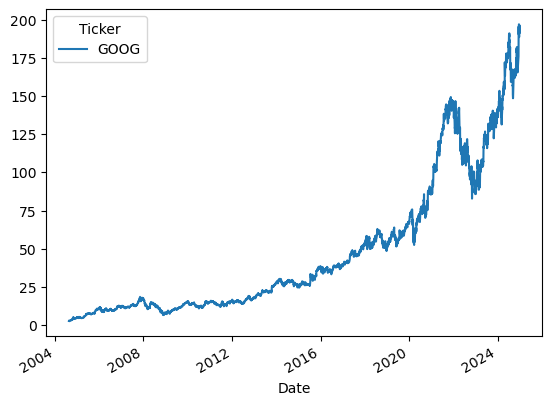

In [14]:
# [+] Lineplot 시각화
goog.plot()

#### <strong> 리샘플링(Resampling)
+ ```resample()```: 빈도를 기준으로 집계 연산
+ ```asfreq()```: 빈도 단위 별 데이터 선택

In [15]:
# [+] 다운샘플링: resample()
goog_downsampled = goog.resample('ME')
goog_downsampled

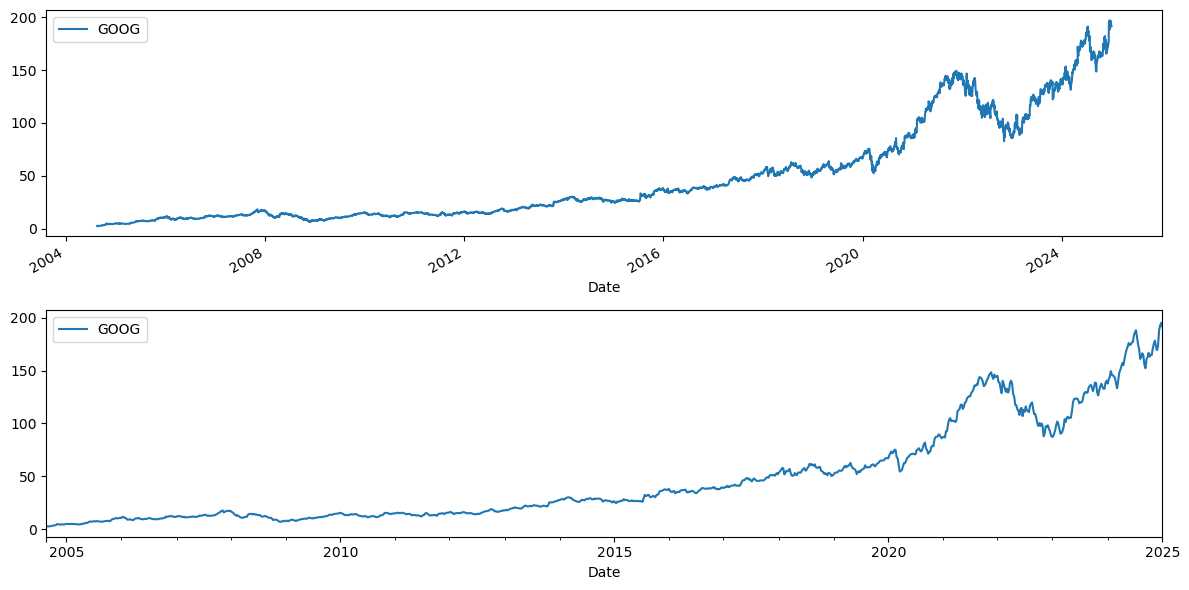

In [16]:
# 혹시 아직 안 하셨다면, 이 코드가 먼저 실행되어야 합니다!
goog_downsampled = goog.resample('W').mean()  # 'W'는 주 단위(Weekly) 예시입니다.

# 그다음 작성하신 코드를 실행하세요.
fig, ax = plt.subplots(2, 1, sharey=True, figsize=(12, 6))
goog.plot(label='original', ax=ax[0])
ax[0].legend()
goog_downsampled.plot(label='downsampled', ax=ax[1])
ax[1].legend()
plt.tight_layout()
plt.show()

Ticker            GOOG
Date                  
2004-08-31    2.528931
2004-09-30    3.201616
2004-10-31         NaN
2004-11-30    4.495602
2004-12-31    4.762651
...                ...
2024-07-31  171.935440
2024-08-31         NaN
2024-09-30  166.235809
2024-10-31  171.704422
2024-11-30         NaN

[244 rows x 1 columns]


C:\Users\USER\AppData\Local\Temp\ipykernel_20364\2305263628.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  goog_downsampled = goog.asfreq('M')


<Axes: xlabel='Date'>

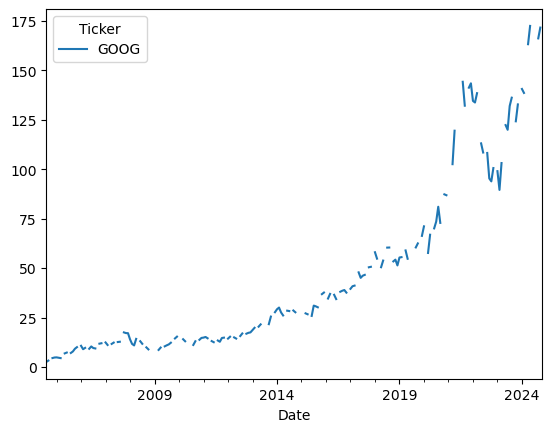

In [17]:
# [+] 다운샘플링: asfreq()
goog_downsampled = goog.asfreq('M')
print(goog_downsampled)

goog_downsampled.plot()

In [18]:
# [+] 업샘플링: resample()
goog_upsampled = goog.resample('12h').mean()
print(goog_upsampled)

Ticker                     GOOG
Date                           
2004-08-19 00:00:00    2.478783
2004-08-19 12:00:00         NaN
2004-08-20 00:00:00    2.675672
2004-08-20 12:00:00         NaN
2004-08-21 00:00:00         NaN
...                         ...
2024-12-28 00:00:00         NaN
2024-12-28 12:00:00         NaN
2024-12-29 00:00:00         NaN
2024-12-29 12:00:00         NaN
2024-12-30 00:00:00  191.807632

[14877 rows x 1 columns]


#### <strong> 시프팅(Shifting)
+ ```shift(periods)``` : ```periods``` 값 만큼 시계열 이동

In [19]:
# [+] 900일 뒤로 시프팅 적용
goog_shifted = goog.shift(periods=900)
goog_shifted

Ticker,GOOG
Date,
2004-08-19,NaN
2004-08-20,NaN
2004-08-23,NaN
2004-08-24,NaN
2004-08-25,NaN
...,...
2024-12-23,120.685669
2024-12-24,119.147324
2024-12-26,119.596123


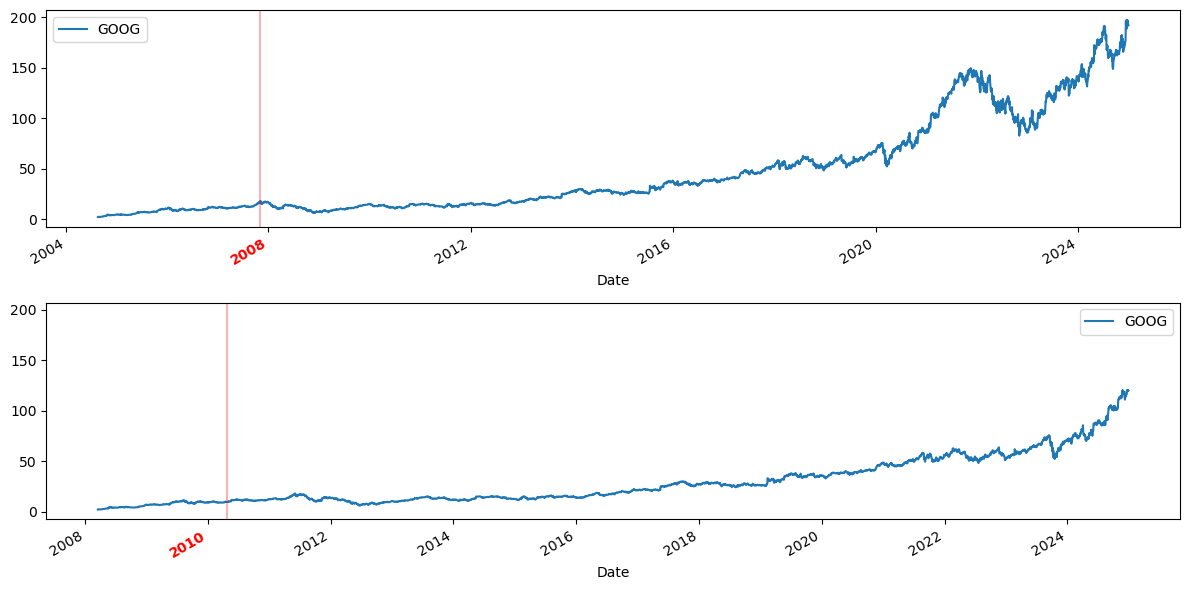

In [20]:
fig, ax = plt.subplots(2, 1, sharey=True, figsize=(12, 6))

# Legends and annotations
local_max = pd.to_datetime('2007-11-05')
offset = pd.Timedelta(900, 'D')

goog.plot(label='original', ax=ax[0])
ax[0].legend()
ax[0].get_xticklabels()[2].set(weight='heavy', color='red')
ax[0].axvline(local_max, alpha=0.3, color='red')

goog_shifted.plot(label='shifted 900 days', ax=ax[1])
ax[1].legend()
ax[1].get_xticklabels()[2].set(weight='heavy', color='red')
ax[1].axvline(local_max + offset, alpha=0.3, color='red')

plt.tight_layout()

In [21]:
# shifting 응용: 주가 변화율 계산
goog_shifted = goog.shift(periods=1) # [+] 시프팅
(goog - goog_shifted) / goog_shifted# [+] 주가 변화율 계산

Ticker,GOOG
Date,
2004-08-19,NaN
2004-08-20,0.079430
2004-08-23,0.010064
2004-08-24,-0.041408
2004-08-25,0.010775
...,...
2024-12-23,0.015703
2024-12-24,0.008062
2024-12-26,-0.002379


Ticker          GOOG
Date                
2004-08-19       NaN
2004-08-20  0.196889
2004-08-23  0.026927
2004-08-24 -0.111908
2004-08-25  0.027915
...              ...
2024-12-23  3.016113
2024-12-24  1.572769
2024-12-26 -0.467850
2024-12-27 -3.045990
2024-12-30 -1.343811

[5126 rows x 1 columns]


<Axes: xlabel='Date'>

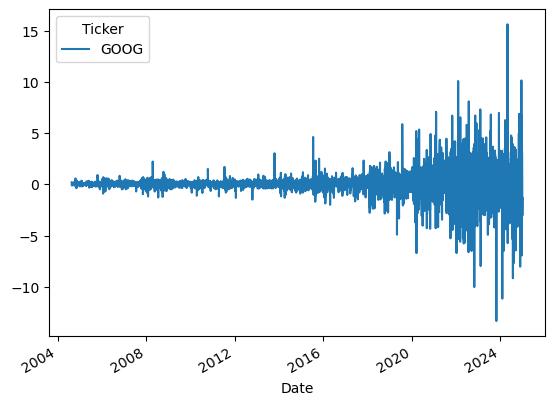

In [22]:
# shifting 응용: 차분 시계열 구하기
goog_diff = goog - goog_shifted  # [+] 차분
print(goog_diff)

goog_diff.plot()

#### <strong> 윈도잉(Windowing)

Rolling [window=730,center=False,axis=0,method=single]


<Axes: xlabel='Date'>

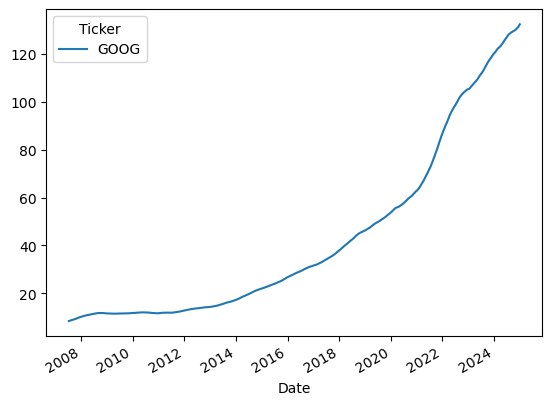

In [23]:
# [+] 365일 단위 윈도잉
goog_rolled = goog.rolling(730)
print(goog_rolled)

goog_rolled.mean().plot()

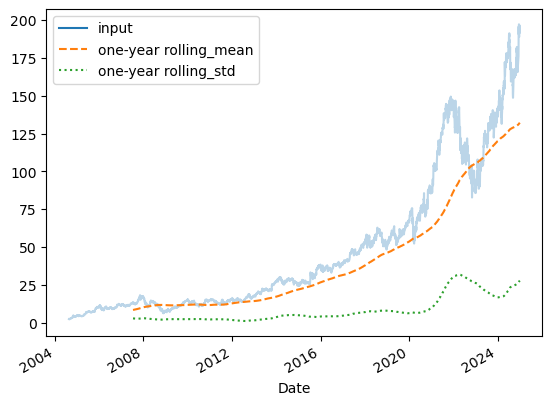

In [24]:
data = pd.DataFrame({'input': goog.values.flatten(),
                     # moving average
                     'one-year rolling_mean': goog_rolled.mean().values.flatten(), 
                     # standard deviation
                     'one-year rolling_std': goog_rolled.std().values.flatten()}, index=goog.index)
ax = data.plot(style=['-', '--', ':'])
ax.lines[0].set_alpha(0.3)